# Euler Method and Aliasing
This notebook compares the analytical solution $f(x)=-\cos(x)$ with forward-Euler integrations using different step sizes.

Smaller step sizes track the exact solution well, while larger step sizes can introduce sampling artifacts (aliasing).

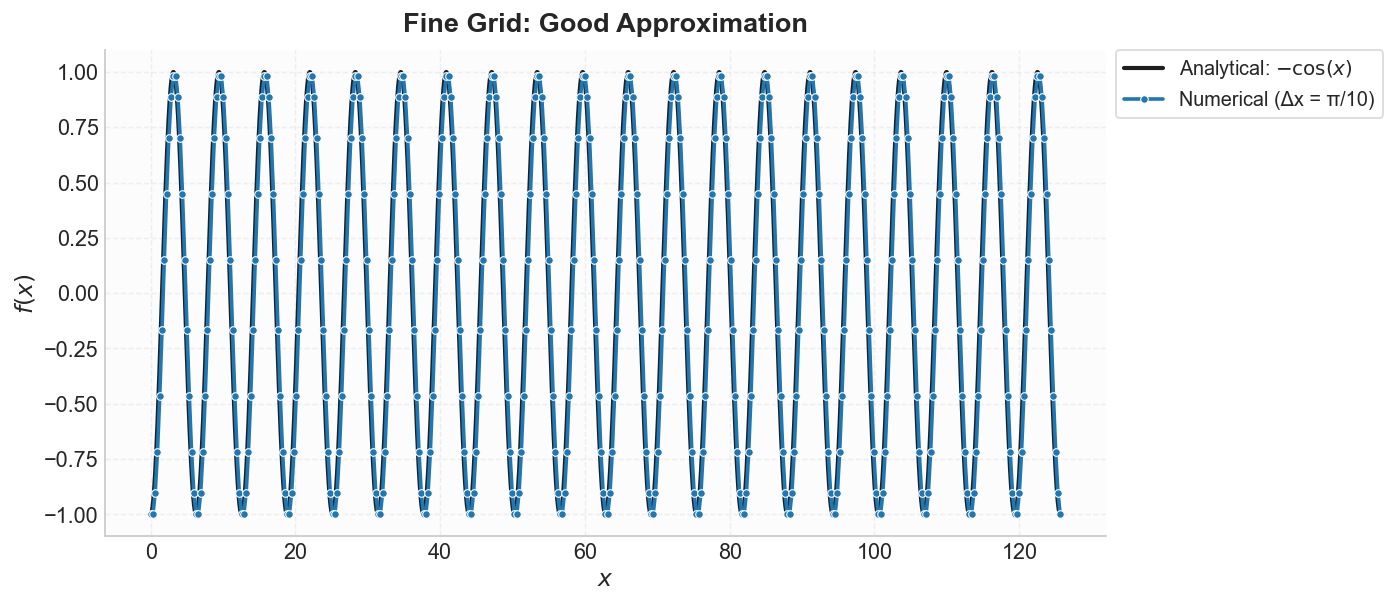

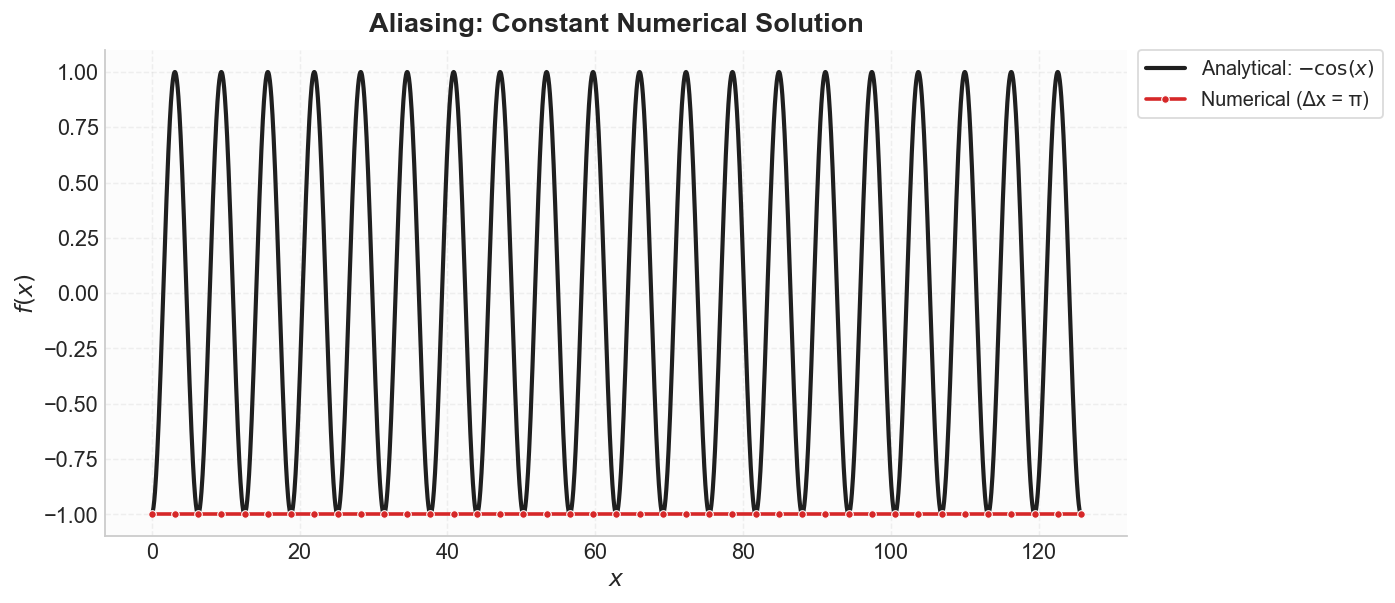

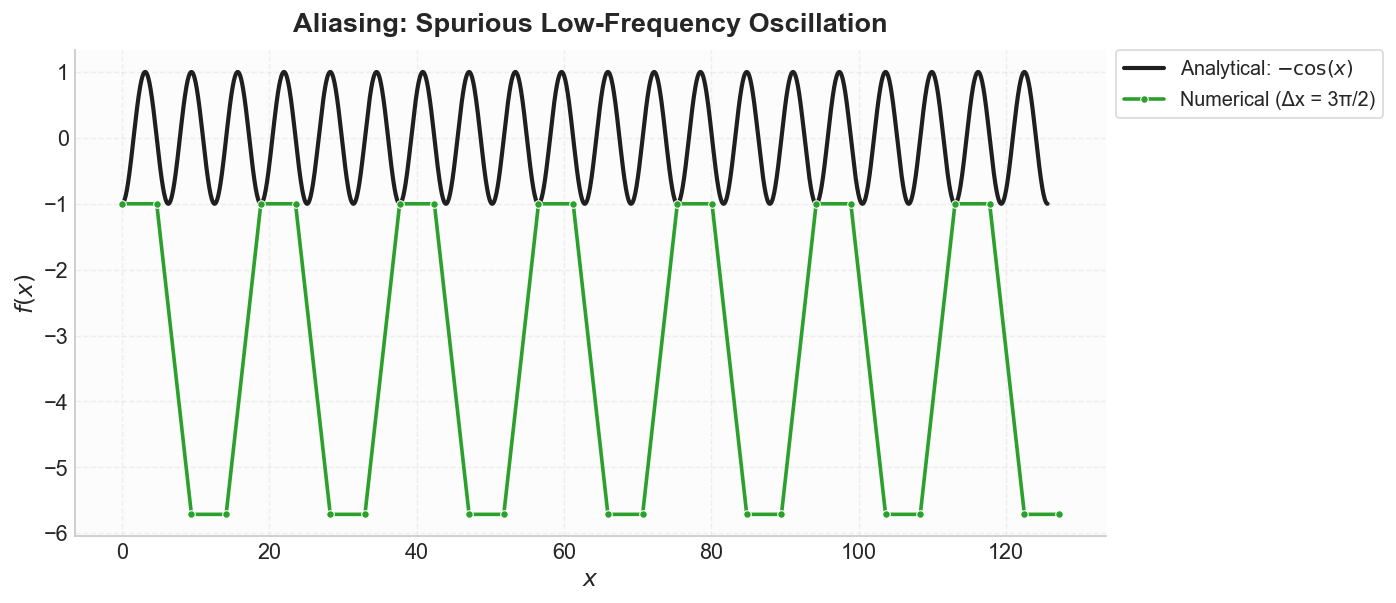

In [4]:
import numpy as np
import matplotlib.pyplot as plt

f0 = -1
x_max = 40 * np.pi

x_dense = np.linspace(0, x_max, 2500)
f_exact = -np.cos(x_dense)


def euler_integration(delta):
    x = np.arange(0, x_max + delta, delta)
    f = np.zeros_like(x)
    f[0] = f0
    for i in range(1, len(x)):
        f[i] = f[i - 1] + delta * np.sin(x[i - 1])
    return x, f


x_fine, f_fine = euler_integration(np.pi / 10)
x_alias1, f_alias1 = euler_integration(np.pi)
x_alias2, f_alias2 = euler_integration(3 * np.pi / 2)


def make_plot(x_num, f_num, title, label, color):
    fig, ax = plt.subplots(figsize=(13, 4.8), dpi=130)
    ax.plot(x_dense, f_exact, label="Analytical: $-\\cos(x)$", color="#1f1f1f", lw=2.3)
    ax.plot(
        x_num,
        f_num,
        "o-",
        label=label,
        color=color,
        lw=2.0,
        markersize=4.2,
        markeredgecolor="white",
        markeredgewidth=0.6,
    )
    ax.set_title(title, pad=10, fontweight="semibold")
    ax.set_xlabel("$x$")
    ax.set_ylabel("$f(x)$")
    ax.grid(alpha=0.28, linestyle="--")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.legend(
        frameon=True,
        facecolor="white",
        edgecolor="#d9d9d9",
        framealpha=0.95,
        loc="upper left",
        bbox_to_anchor=(1.01, 1.0),
        borderaxespad=0.0,
    )
    fig.tight_layout(rect=[0, 0, 0.84, 1])
    return fig, ax


plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update(
    {
        "font.size": 12,
        "axes.titlesize": 15,
        "axes.labelsize": 13,
        "legend.fontsize": 11,
        "figure.facecolor": "white",
        "axes.facecolor": "#fcfcfc",
    }
)

make_plot(
    x_fine,
    f_fine,
    "Fine Grid: Good Approximation",
    "Numerical (Δx = π/10)",
    "#1f77b4",
)

make_plot(
    x_alias1,
    f_alias1,
    "Aliasing: Constant Numerical Solution",
    "Numerical (Δx = π)",
    "#d62728",
)

make_plot(
    x_alias2,
    f_alias2,
    "Aliasing: Spurious Low-Frequency Oscillation",
    "Numerical (Δx = 3π/2)",
    "#2ca02c",
)

plt.show()